# Energy Market Data Exploration

This notebook is the first exploratory consumer of `YFinanceDailyAdapter`. It pulls daily Yahoo Finance series into the core `DataService`, then builds a few lightweight views for the energy/oil story.

The futures-like Yahoo symbols here (`CL=F`, `BZ=F`, and related fuels) are continuous front-month-style proxies. They are useful for orientation, but not a substitute for a contract-level futures data source.

In [1]:
from __future__ import annotations

import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "data.py").exists():
    NOTEBOOK_DIR = Path("playground/energy_yfinance").resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from data import CATEGORY_LABELS, build_energy_market_service  # noqa: E402


pd.options.display.float_format = "{:.3f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## Load Market Data

The first run downloads from Yahoo Finance and writes parquet files under the repo-root `data/yfinance/` cache. Warm-cache runs do not touch the network unless `REFRESH = True`.

In [2]:
def find_repo_root(start: Path) -> Path:
    """Walk upward until the repository root pyproject is found."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "aieng-forecasting").exists():
            return candidate
    raise RuntimeError("Could not locate repository root")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
CACHE_DIR = REPO_ROOT / "data" / "yfinance"
START = "2005-01-01"
END = None
REFRESH = False

service = build_energy_market_service(start=START, end=END, cache_dir=CACHE_DIR, refresh=REFRESH)
summary = service.summary()
summary.insert(1, "label", summary["series_id"].map(CATEGORY_LABELS))
summary

,series_id,label,description,source,units,frequency,n_obs,start,end
0,brent_crude_oil_front_month,Brent crude,Brent crude oil continuous front-month futures...,Yahoo Finance (BZ=F),USD,B,4665,2007-07-30,2026-04-28
1,energy_select_sector_spdr,XLE energy equities,Energy Select Sector SPDR ETF adjusted close f...,Yahoo Finance (XLE),USD,B,5363,2005-01-03,2026-04-28
2,heating_oil_front_month,Heating oil,Heating oil continuous front-month futures pro...,Yahoo Finance (HO=F),USD,B,5362,2005-01-03,2026-04-28
3,natural_gas_front_month,Natural gas,Natural gas continuous front-month futures pro...,Yahoo Finance (NG=F),USD,B,5363,2005-01-03,2026-04-28
4,rbob_gasoline_front_month,RBOB gasoline,RBOB gasoline continuous front-month futures p...,Yahoo Finance (RB=F),USD,B,5365,2005-01-03,2026-04-28
5,sp500_index,S&P 500,S&P 500 index adjusted close from Yahoo Finance,Yahoo Finance (^GSPC),USD,B,5363,2005-01-03,2026-04-28
6,us_dollar_index,US dollar index,US Dollar Index adjusted close from Yahoo Finance,Yahoo Finance (DX-Y.NYB),USD,B,5369,2005-01-03,2026-04-28
7,wti_crude_oil_front_month,WTI crude,WTI crude oil continuous front-month futures p...,Yahoo Finance (CL=F),USD,B,5362,2005-01-03,2026-04-28


In [3]:
as_of = datetime.now()
frames: list[pd.DataFrame] = []
for series_id in service.series_ids:
    frame = service.get_series(series_id, as_of=as_of)[["timestamp", "value"]].copy()
    frame["series_id"] = series_id
    frames.append(frame)

prices = pd.concat(frames, ignore_index=True)
wide = prices.pivot(index="timestamp", columns="series_id", values="value").sort_index()
wide.tail()

series_id,brent_crude_oil_front_month,energy_select_sector_spdr,heating_oil_front_month,natural_gas_front_month,rbob_gasoline_front_month,sp500_index,us_dollar_index,wti_crude_oil_front_month
timestamp,,,,,,,,
2026-04-21,98.480,55.870,3.729,2.697,3.210,7064.010,98.410,92.130
2026-04-22,101.910,56.540,3.938,2.722,3.358,7137.900,98.590,92.960
2026-04-23,105.070,56.980,3.988,2.614,3.462,7108.400,98.800,95.850
2026-04-24,105.330,56.870,3.887,2.523,3.463,7165.080,98.510,94.400
2026-04-27,108.230,56.770,3.975,2.550,3.491,7173.910,98.480,96.370


## Normalized Price Levels

Each series starts at 100 from its first available observation, making long-run co-movement easier to compare despite different units and start dates.

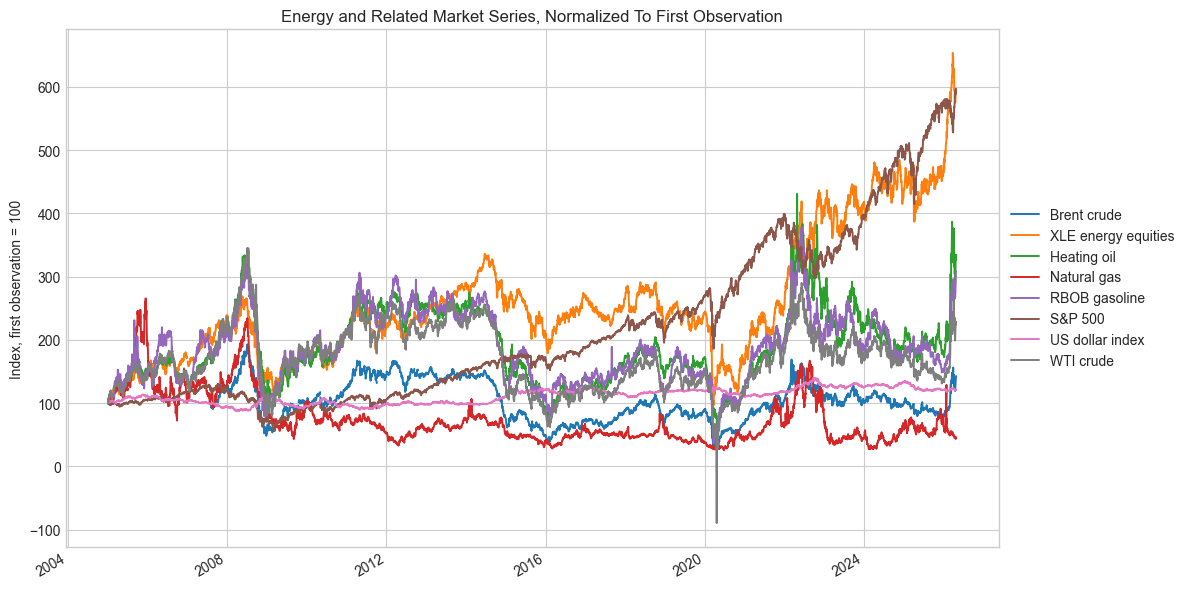

In [4]:
def normalize_to_first_observation(series: pd.Series) -> pd.Series:
    """Scale a price series to 100 at its first valid observation."""
    valid = series.dropna()
    if valid.empty:
        return series
    return series / valid.iloc[0] * 100


normalized = wide.apply(normalize_to_first_observation).rename(columns=CATEGORY_LABELS)
ax = normalized.plot(figsize=(12, 6), linewidth=1.4)
ax.set_title("Energy and Related Market Series, Normalized To First Observation")
ax.set_ylabel("Index, first observation = 100")
ax.set_xlabel("")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

## Recent Window

The recent window is more useful for presentation framing because the May 2026 story is about current conditions and forward-looking risks.

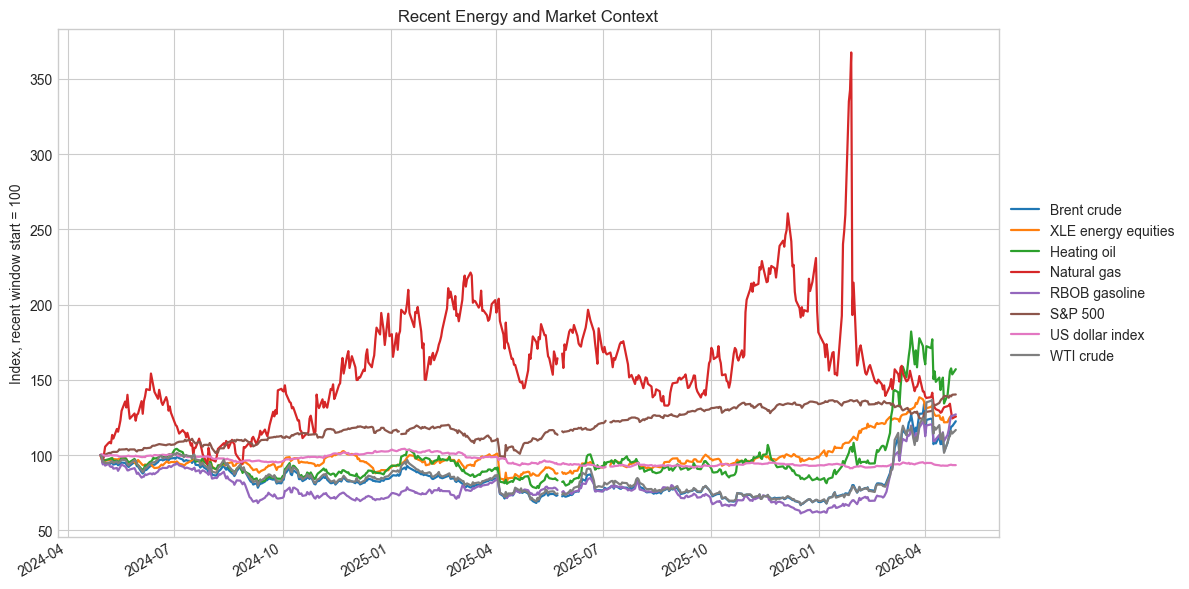

In [5]:
recent_start = wide.index.max() - pd.DateOffset(years=2)
recent = wide.loc[wide.index >= recent_start]
recent_normalized = recent.apply(normalize_to_first_observation).rename(columns=CATEGORY_LABELS)

ax = recent_normalized.plot(figsize=(12, 6), linewidth=1.6)
ax.set_title("Recent Energy and Market Context")
ax.set_ylabel("Index, recent window start = 100")
ax.set_xlabel("")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

## Returns, Volatility, And Correlation

Daily returns make cross-market relationships easier to inspect than raw levels. This is still descriptive, not a forecasting model.

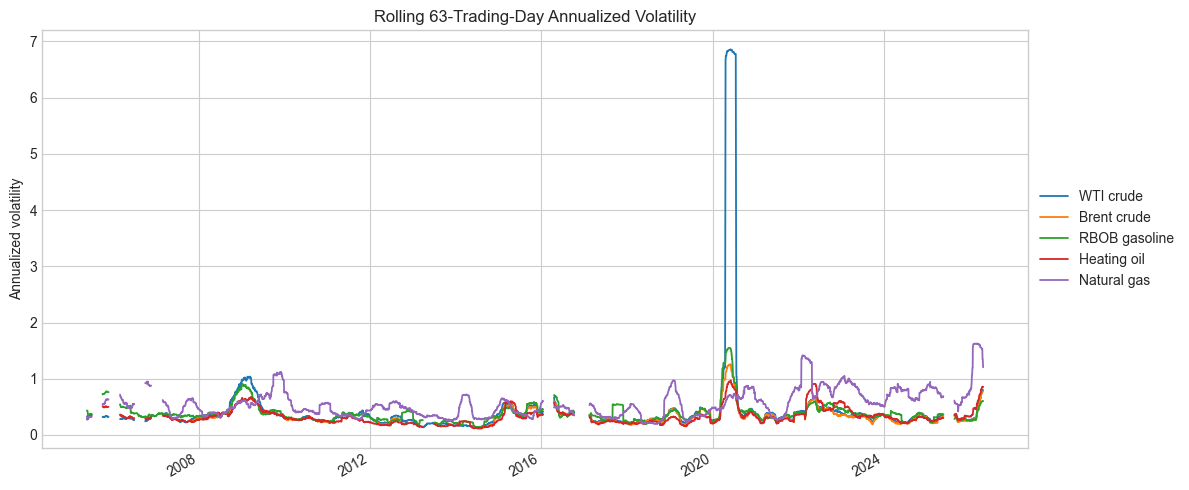

In [6]:
returns = wide.pct_change(fill_method=None).dropna(how="all")
annualized_vol = returns.rolling(63).std() * (252**0.5)

oil_and_fuels = [
    "wti_crude_oil_front_month",
    "brent_crude_oil_front_month",
    "rbob_gasoline_front_month",
    "heating_oil_front_month",
    "natural_gas_front_month",
]
ax = annualized_vol[oil_and_fuels].rename(columns=CATEGORY_LABELS).plot(figsize=(12, 5), linewidth=1.3)
ax.set_title("Rolling 63-Trading-Day Annualized Volatility")
ax.set_ylabel("Annualized volatility")
ax.set_xlabel("")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

In [7]:
recent_returns = returns.loc[returns.index >= returns.index.max() - pd.DateOffset(years=3)]
correlation = recent_returns.rename(columns=CATEGORY_LABELS).corr()
correlation.style.format("{:.2f}").background_gradient(cmap="coolwarm", vmin=-1, vmax=1)

series_id,Brent crude,XLE energy equities,Heating oil,Natural gas,RBOB gasoline,S&P 500,US dollar index,WTI crude
series_id,,,,,,,,
Brent crude,1.00,0.57,0.79,0.09,0.77,0.04,0.14,0.94
XLE energy equities,0.57,1.00,0.47,0.15,0.49,0.40,0.06,0.56
Heating oil,0.79,0.47,1.00,0.19,0.69,-0.02,0.14,0.79
Natural gas,0.09,0.15,0.19,1.00,0.07,0.04,-0.00,0.08
RBOB gasoline,0.77,0.49,0.69,0.07,1.00,0.05,0.11,0.76
S&P 500,0.04,0.40,-0.02,0.04,0.05,1.00,-0.06,0.02
US dollar index,0.14,0.06,0.14,-0.00,0.11,-0.06,1.00,0.14
WTI crude,0.94,0.56,0.79,0.08,0.76,0.02,0.14,1.00


## Fast Follow: Futures Data

Before treating futures seriously, investigate contract-level sources, roll rules, curve snapshots, open interest, volume, and licensing. Yahoo Finance is enough for this first exploratory pass, but not enough for futures-curve semantics.